# Task 5: Strategy Backtesting

**Objective:** Validate the model-driven portfolio strategy from Task 4 by simulating its performance on historical out-of-sample data and comparing it against a benchmark.

**Approach:**
- **Strategy Portfolio:** Max Sharpe weights from Task 4 (TSLA: 0%, BND: 0%, SPY: 100%)
- **Benchmark:** Static 60% SPY / 40% BND (common balanced portfolio)
- **Backtesting Window:** January 2025 – June 2026 (out-of-sample data not used in model training)
- **Variants:** Both buy-and-hold and monthly rebalancing

**Deliverables:**
1. Cumulative returns comparison plot (strategy vs. benchmark)
2. Performance metrics table for both portfolios
3. Written conclusion on strategy viability

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import json
import os
import warnings

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

processed_dir = os.path.join('..', 'data', 'processed')
print("All imports successful.")

All imports successful.


In [2]:
# Load data
close_prices = pd.read_csv(os.path.join(processed_dir, 'close_prices.csv'),
                           index_col=0, parse_dates=True)

with open(os.path.join(processed_dir, 'portfolio_config.json')) as f:
    portfolio_config = json.load(f)

# Define backtesting window
bt_start = '2025-01-01'
bt_data = close_prices[close_prices.index >= bt_start][['TSLA', 'BND', 'SPY']].dropna()
bt_returns = bt_data.pct_change().dropna()

print(f"Backtesting period: {bt_data.index.min().date()} to {bt_data.index.max().date()}")
print(f"Trading days: {len(bt_returns)}")
print(f"\nStrategy (Max Sharpe) weights: TSLA={portfolio_config['weights']['TSLA']:.1%}, "
      f"BND={portfolio_config['weights']['BND']:.1%}, SPY={portfolio_config['weights']['SPY']:.1%}")
print(f"Benchmark weights: SPY=60%, BND=40%")

Backtesting period: 2025-01-02 to 2026-06-29
Trading days: 371

Strategy (Max Sharpe) weights: TSLA=0.0%, BND=0.0%, SPY=100.0%
Benchmark weights: SPY=60%, BND=40%


## 2. Define Portfolios and Benchmark

In [3]:
# Portfolio weight definitions
strategy_weights = np.array([portfolio_config['weights']['TSLA'],
                             portfolio_config['weights']['BND'],
                             portfolio_config['weights']['SPY']])

benchmark_weights = np.array([0.0, 0.40, 0.60])  # 60% SPY / 40% BND

risk_free_rate = portfolio_config['risk_free_rate']

print("Portfolio Definitions:")
print(f"  Strategy (Max Sharpe):  TSLA={strategy_weights[0]:.0%}, BND={strategy_weights[1]:.0%}, SPY={strategy_weights[2]:.0%}")
print(f"  Benchmark (60/40):     TSLA={benchmark_weights[0]:.0%}, BND={benchmark_weights[1]:.0%}, SPY={benchmark_weights[2]:.0%}")
print(f"  Risk-free rate: {risk_free_rate:.1%}")

Portfolio Definitions:
  Strategy (Max Sharpe):  TSLA=0%, BND=0%, SPY=100%
  Benchmark (60/40):     TSLA=0%, BND=40%, SPY=60%
  Risk-free rate: 4.5%


## 3. Simulate Portfolios

### 3.1 Buy-and-Hold Strategy
Invest with initial weights at the start and let positions drift with market movements (no rebalancing).

In [4]:
def simulate_buy_and_hold(prices, initial_weights):
    """Simulate buy-and-hold: invest at initial weights, no rebalancing."""
    normalized = prices / prices.iloc[0]
    portfolio_value = (normalized * initial_weights).sum(axis=1)
    return portfolio_value

# Buy-and-hold simulation
strategy_bh = simulate_buy_and_hold(bt_data, strategy_weights)
benchmark_bh = simulate_buy_and_hold(bt_data, benchmark_weights)

print("Buy-and-Hold Simulation:")
print(f"  Strategy final value (per $1): ${strategy_bh.iloc[-1]:.4f}")
print(f"  Benchmark final value (per $1): ${benchmark_bh.iloc[-1]:.4f}")
print(f"  Strategy total return: {(strategy_bh.iloc[-1] - 1)*100:.2f}%")
print(f"  Benchmark total return: {(benchmark_bh.iloc[-1] - 1)*100:.2f}%")

Buy-and-Hold Simulation:
  Strategy final value (per $1): $1.2674
  Benchmark final value (per $1): $1.1703
  Strategy total return: 26.74%
  Benchmark total return: 17.03%


### 3.2 Monthly Rebalancing Strategy
Rebalance back to target weights at the start of each month.

In [5]:
def simulate_rebalanced(prices, target_weights, rebalance_freq='MS'):
    """Simulate portfolio with periodic rebalancing to target weights."""
    daily_returns = prices.pct_change().dropna()
    
    # Get rebalance dates (first trading day of each month)
    rebalance_dates = daily_returns.resample(rebalance_freq).first().index
    rebalance_dates = [d for d in rebalance_dates if d in daily_returns.index]
    
    portfolio_value = [1.0]
    current_weights = target_weights.copy()
    
    for i, date in enumerate(daily_returns.index):
        if date in rebalance_dates:
            current_weights = target_weights.copy()
        
        day_return = np.dot(current_weights, daily_returns.loc[date].values)
        new_value = portfolio_value[-1] * (1 + day_return)
        portfolio_value.append(new_value)
        
        # Update weights based on drift
        asset_values = current_weights * (1 + daily_returns.loc[date].values)
        total = asset_values.sum()
        if total > 0:
            current_weights = asset_values / total
    
    return pd.Series(portfolio_value[1:], index=daily_returns.index)

# Monthly rebalanced simulation
strategy_rb = simulate_rebalanced(bt_data, strategy_weights)
benchmark_rb = simulate_rebalanced(bt_data, benchmark_weights)

print("Monthly Rebalanced Simulation:")
print(f"  Strategy final value (per $1): ${strategy_rb.iloc[-1]:.4f}")
print(f"  Benchmark final value (per $1): ${benchmark_rb.iloc[-1]:.4f}")
print(f"  Strategy total return: {(strategy_rb.iloc[-1] - 1)*100:.2f}%")
print(f"  Benchmark total return: {(benchmark_rb.iloc[-1] - 1)*100:.2f}%")

Monthly Rebalanced Simulation:
  Strategy final value (per $1): $1.2674
  Benchmark final value (per $1): $1.1687
  Strategy total return: 26.74%
  Benchmark total return: 16.87%


## 4. Performance Metrics

In [6]:
def calculate_performance_metrics(portfolio_values, risk_free_rate=0.045):
    """Calculate comprehensive performance metrics."""
    returns = portfolio_values.pct_change().dropna()
    n_days = len(returns)
    n_years = n_days / 252
    
    # Total return
    total_return = (portfolio_values.iloc[-1] / portfolio_values.iloc[0]) - 1
    
    # Annualized return
    annualized_return = (1 + total_return) ** (1 / n_years) - 1
    
    # Annualized volatility
    annualized_vol = returns.std() * np.sqrt(252)
    
    # Sharpe ratio
    sharpe = (annualized_return - risk_free_rate) / annualized_vol if annualized_vol > 0 else 0
    
    # Maximum drawdown
    rolling_max = portfolio_values.cummax()
    drawdown = (portfolio_values - rolling_max) / rolling_max
    max_drawdown = drawdown.min()
    
    # Sortino ratio (downside deviation)
    downside_returns = returns[returns < 0]
    downside_std = downside_returns.std() * np.sqrt(252)
    sortino = (annualized_return - risk_free_rate) / downside_std if downside_std > 0 else 0
    
    # Calmar ratio
    calmar = annualized_return / abs(max_drawdown) if max_drawdown != 0 else 0
    
    return {
        'Total Return': f"{total_return*100:.2f}%",
        'Annualized Return': f"{annualized_return*100:.2f}%",
        'Annualized Volatility': f"{annualized_vol*100:.2f}%",
        'Sharpe Ratio': f"{sharpe:.4f}",
        'Sortino Ratio': f"{sortino:.4f}",
        'Max Drawdown': f"{max_drawdown*100:.2f}%",
        'Calmar Ratio': f"{calmar:.4f}"
    }

# Calculate metrics for all variants
metrics_strategy_bh = calculate_performance_metrics(strategy_bh, risk_free_rate)
metrics_benchmark_bh = calculate_performance_metrics(benchmark_bh, risk_free_rate)
metrics_strategy_rb = calculate_performance_metrics(strategy_rb, risk_free_rate)
metrics_benchmark_rb = calculate_performance_metrics(benchmark_rb, risk_free_rate)

# Display comparison table
metrics_table = pd.DataFrame({
    'Strategy (B&H)': metrics_strategy_bh,
    'Benchmark (B&H)': metrics_benchmark_bh,
    'Strategy (Rebal.)': metrics_strategy_rb,
    'Benchmark (Rebal.)': metrics_benchmark_rb
})

print("=" * 85)
print("PERFORMANCE METRICS COMPARISON")
print("=" * 85)
print(f"Strategy: 100% SPY (Max Sharpe from Task 4)")
print(f"Benchmark: 60% SPY / 40% BND")
print(f"Period: {bt_data.index.min().date()} to {bt_data.index.max().date()}")
print("-" * 85)
print(metrics_table.to_string())
print("=" * 85)

PERFORMANCE METRICS COMPARISON
Strategy: 100% SPY (Max Sharpe from Task 4)
Benchmark: 60% SPY / 40% BND
Period: 2025-01-02 to 2026-06-29
-------------------------------------------------------------------------------------
                      Strategy (B&H) Benchmark (B&H) Strategy (Rebal.) Benchmark (Rebal.)
Total Return                  26.74%          17.03%            25.18%             16.05%
Annualized Return             17.47%          11.27%            16.53%             10.67%
Annualized Volatility         17.94%          11.12%            17.94%             11.11%
Sharpe Ratio                  0.7227          0.6089            0.6704             0.5556
Sortino Ratio                 0.9520          0.8217            0.8831             0.7459
Max Drawdown                 -19.00%         -11.51%           -19.00%            -11.66%
Calmar Ratio                  0.9193          0.9798            0.8699             0.9157


## 5. Visualize Cumulative Returns

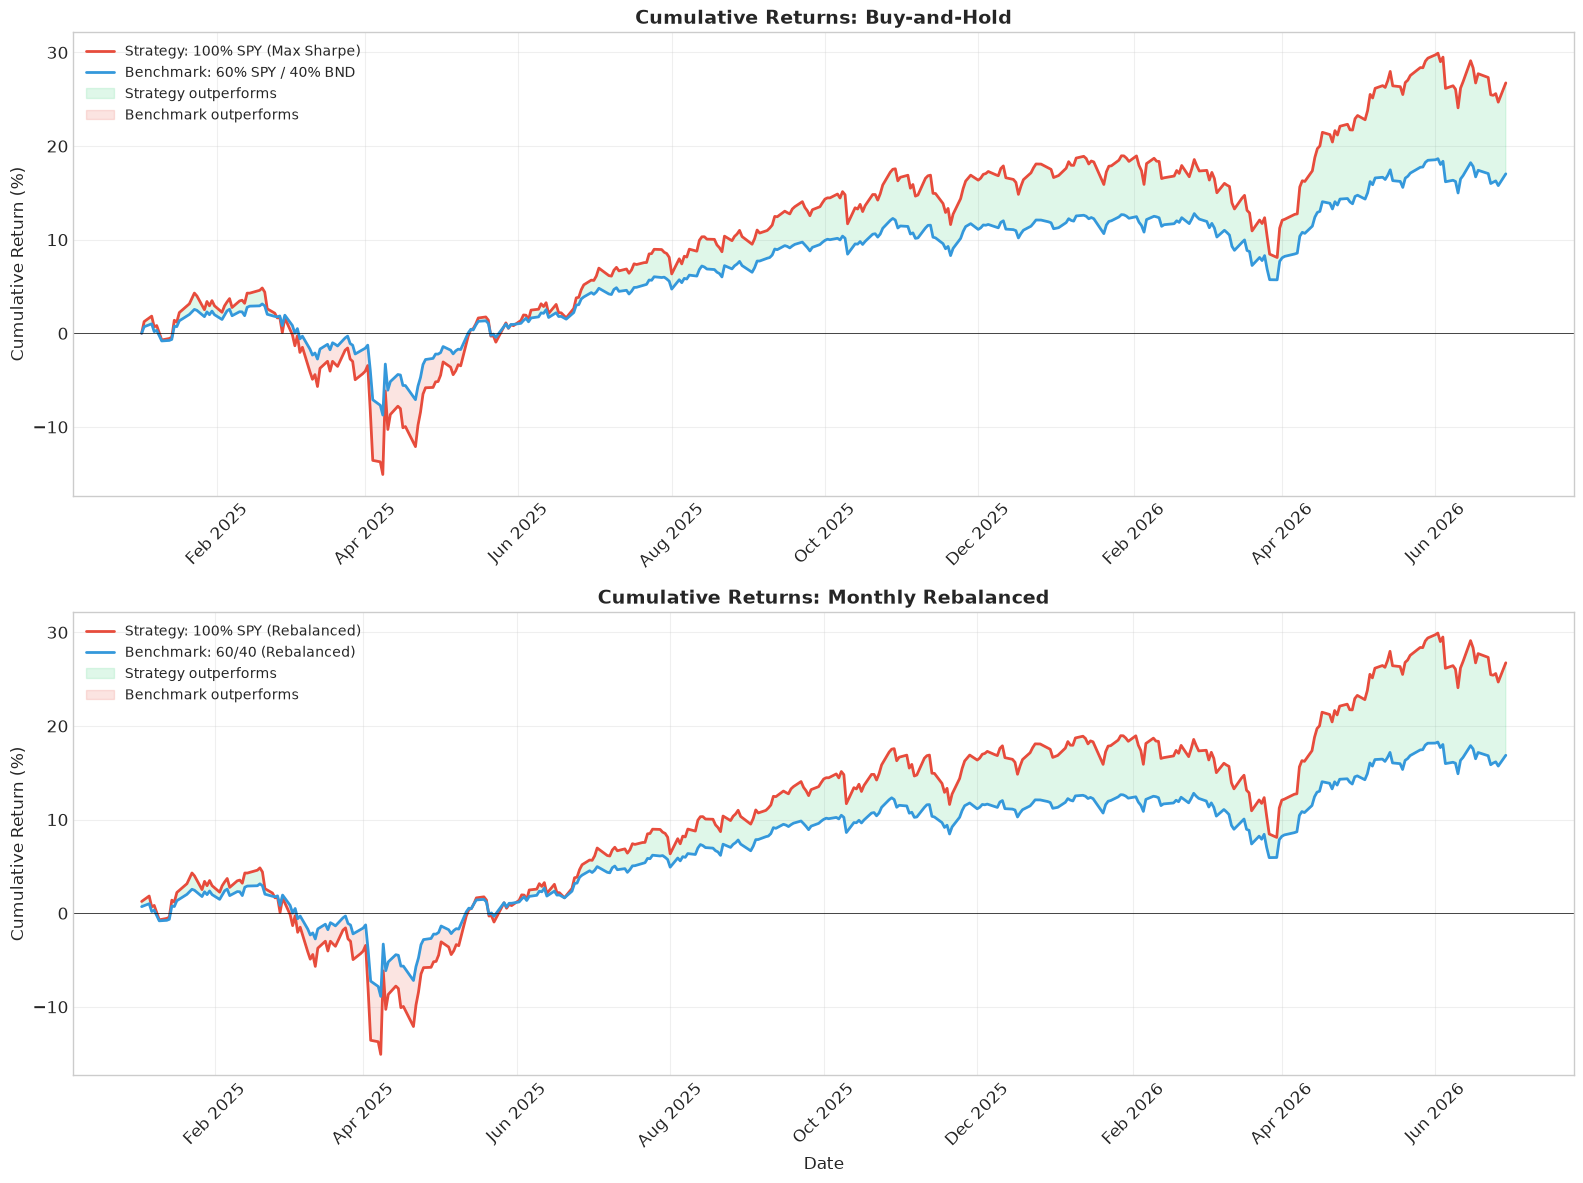

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# --- Buy-and-Hold ---
ax = axes[0]
ax.plot(strategy_bh.index, (strategy_bh - 1) * 100, color='#e74c3c',
        linewidth=2, label='Strategy: 100% SPY (Max Sharpe)')
ax.plot(benchmark_bh.index, (benchmark_bh - 1) * 100, color='#3498db',
        linewidth=2, label='Benchmark: 60% SPY / 40% BND')
ax.axhline(y=0, color='black', linewidth=0.5, linestyle='-')
ax.fill_between(strategy_bh.index,
                (strategy_bh - 1) * 100, (benchmark_bh - 1) * 100,
                where=(strategy_bh > benchmark_bh),
                color='#2ecc71', alpha=0.15, label='Strategy outperforms')
ax.fill_between(strategy_bh.index,
                (strategy_bh - 1) * 100, (benchmark_bh - 1) * 100,
                where=(strategy_bh <= benchmark_bh),
                color='#e74c3c', alpha=0.15, label='Benchmark outperforms')
ax.set_title('Cumulative Returns: Buy-and-Hold', fontsize=14, fontweight='bold')
ax.set_ylabel('Cumulative Return (%)')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# --- Monthly Rebalanced ---
ax = axes[1]
ax.plot(strategy_rb.index, (strategy_rb - 1) * 100, color='#e74c3c',
        linewidth=2, label='Strategy: 100% SPY (Rebalanced)')
ax.plot(benchmark_rb.index, (benchmark_rb - 1) * 100, color='#3498db',
        linewidth=2, label='Benchmark: 60/40 (Rebalanced)')
ax.axhline(y=0, color='black', linewidth=0.5, linestyle='-')
ax.fill_between(strategy_rb.index,
                (strategy_rb - 1) * 100, (benchmark_rb - 1) * 100,
                where=(strategy_rb > benchmark_rb),
                color='#2ecc71', alpha=0.15, label='Strategy outperforms')
ax.fill_between(strategy_rb.index,
                (strategy_rb - 1) * 100, (benchmark_rb - 1) * 100,
                where=(strategy_rb <= benchmark_rb),
                color='#e74c3c', alpha=0.15, label='Benchmark outperforms')
ax.set_title('Cumulative Returns: Monthly Rebalanced', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return (%)')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'backtest_cumulative_returns.png'), dpi=150, bbox_inches='tight')
plt.show()

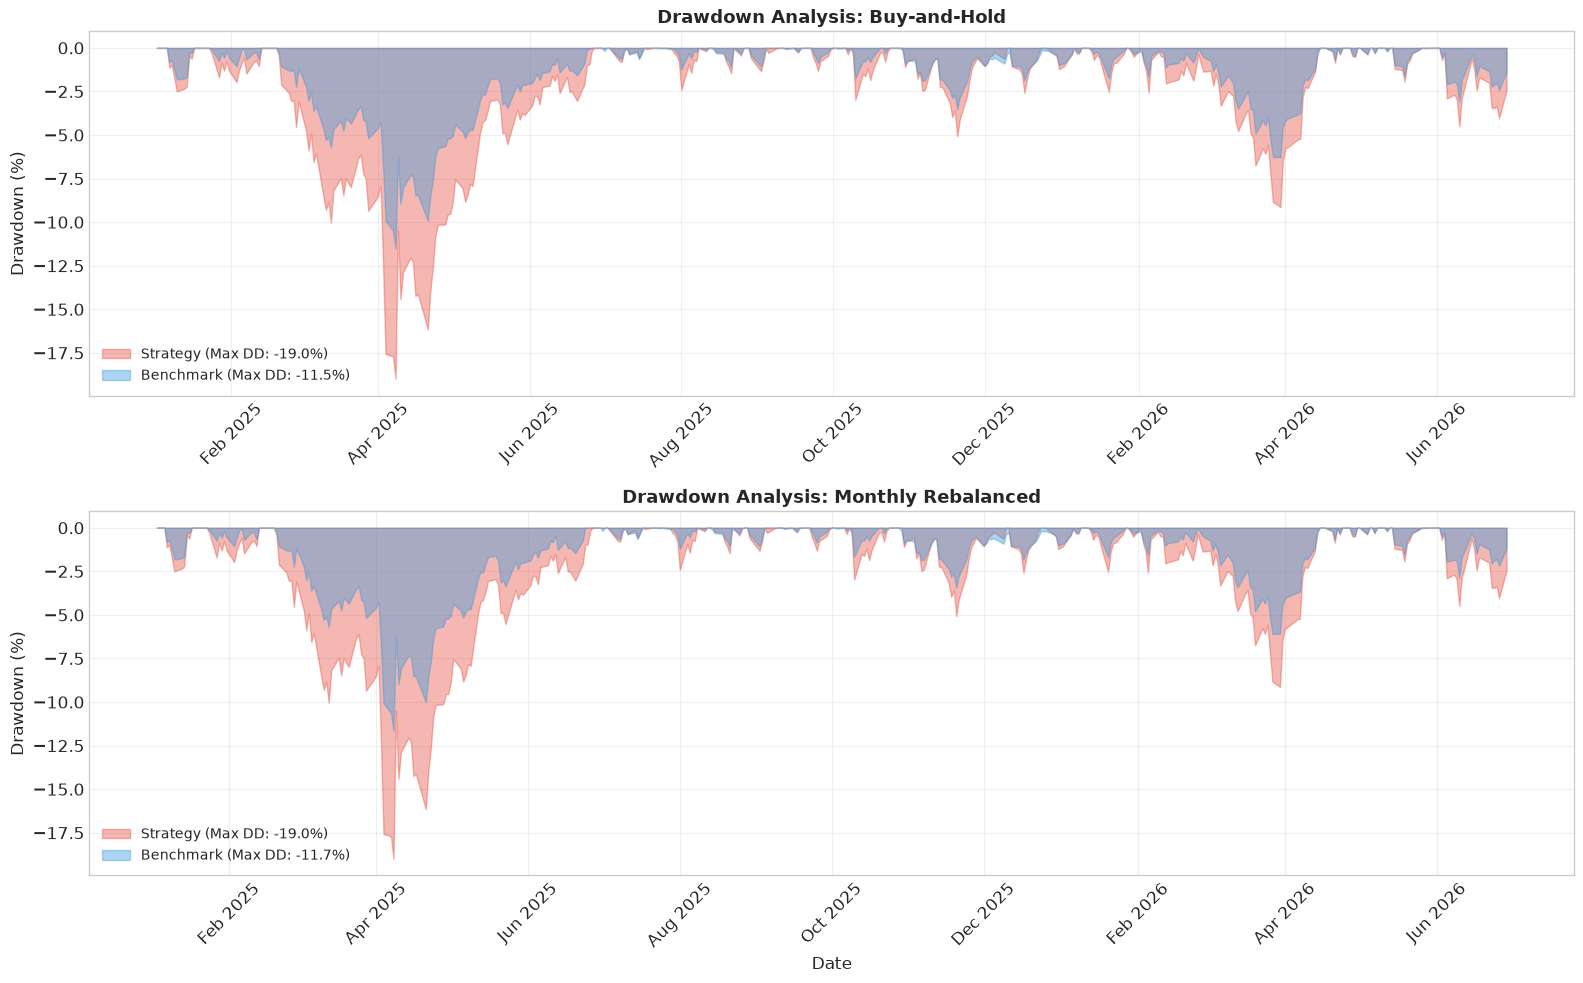

In [8]:
# Drawdown comparison
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

for ax, strat, bench, title in [
    (axes[0], strategy_bh, benchmark_bh, 'Buy-and-Hold'),
    (axes[1], strategy_rb, benchmark_rb, 'Monthly Rebalanced')
]:
    # Strategy drawdown
    strat_dd = (strat - strat.cummax()) / strat.cummax() * 100
    bench_dd = (bench - bench.cummax()) / bench.cummax() * 100
    
    ax.fill_between(strat_dd.index, strat_dd, 0, color='#e74c3c', alpha=0.4,
                    label=f'Strategy (Max DD: {strat_dd.min():.1f}%)')
    ax.fill_between(bench_dd.index, bench_dd, 0, color='#3498db', alpha=0.4,
                    label=f'Benchmark (Max DD: {bench_dd.min():.1f}%)')
    ax.set_title(f'Drawdown Analysis: {title}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Drawdown (%)')
    ax.legend(loc='lower left', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

axes[1].set_xlabel('Date')
plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'backtest_drawdowns.png'), dpi=150, bbox_inches='tight')
plt.show()

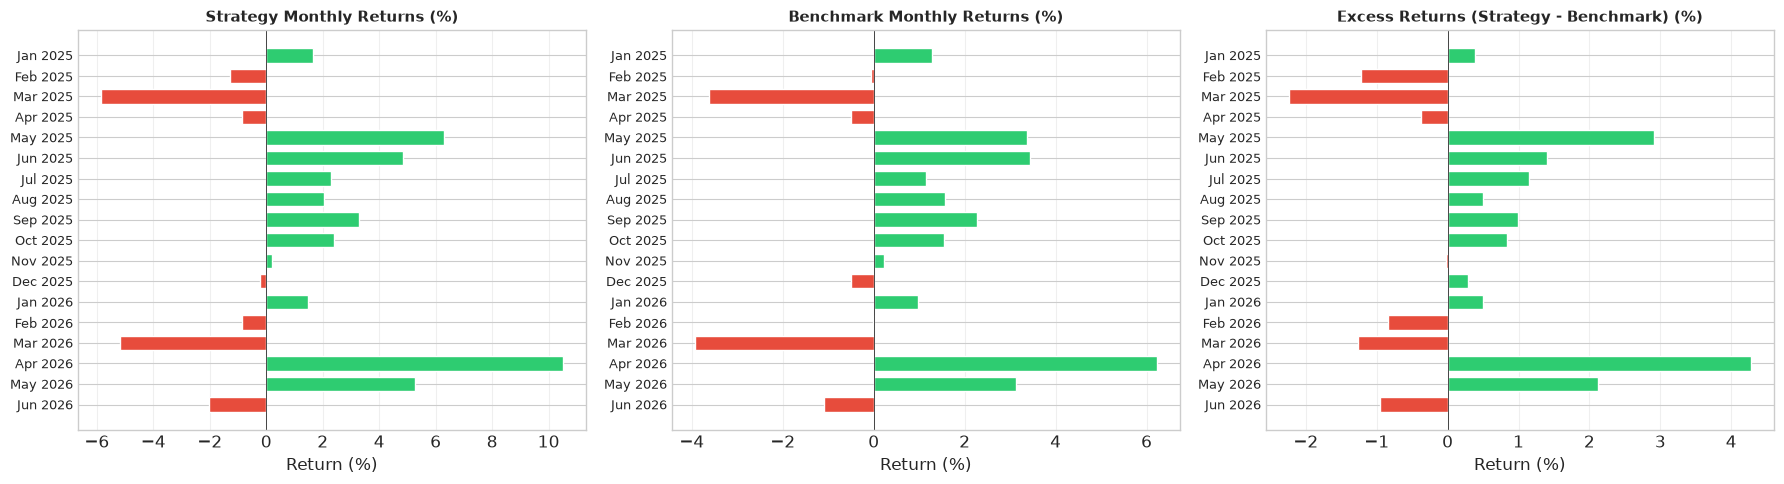

In [9]:
# Monthly returns heatmap
strategy_daily_rets = strategy_rb.pct_change().dropna()
benchmark_daily_rets = benchmark_rb.pct_change().dropna()

# Monthly returns
strat_monthly = strategy_daily_rets.resample('ME').apply(lambda x: (1 + x).prod() - 1) * 100
bench_monthly = benchmark_daily_rets.resample('ME').apply(lambda x: (1 + x).prod() - 1) * 100
excess_monthly = strat_monthly - bench_monthly

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, data, title, cmap in [
    (axes[0], strat_monthly, 'Strategy Monthly Returns (%)', 'RdYlGn'),
    (axes[1], bench_monthly, 'Benchmark Monthly Returns (%)', 'RdYlGn'),
    (axes[2], excess_monthly, 'Excess Returns (Strategy - Benchmark) (%)', 'RdYlGn')
]:
    month_labels = [d.strftime('%b %Y') for d in data.index]
    values = data.values.reshape(-1, 1)
    
    im = ax.barh(range(len(month_labels)), data.values,
                 color=[('#2ecc71' if v >= 0 else '#e74c3c') for v in data.values],
                 edgecolor='white', height=0.7)
    ax.set_yticks(range(len(month_labels)))
    ax.set_yticklabels(month_labels, fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Return (%)')
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.grid(True, alpha=0.3, axis='x')
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'backtest_monthly_returns.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Individual Asset Performance During Backtest

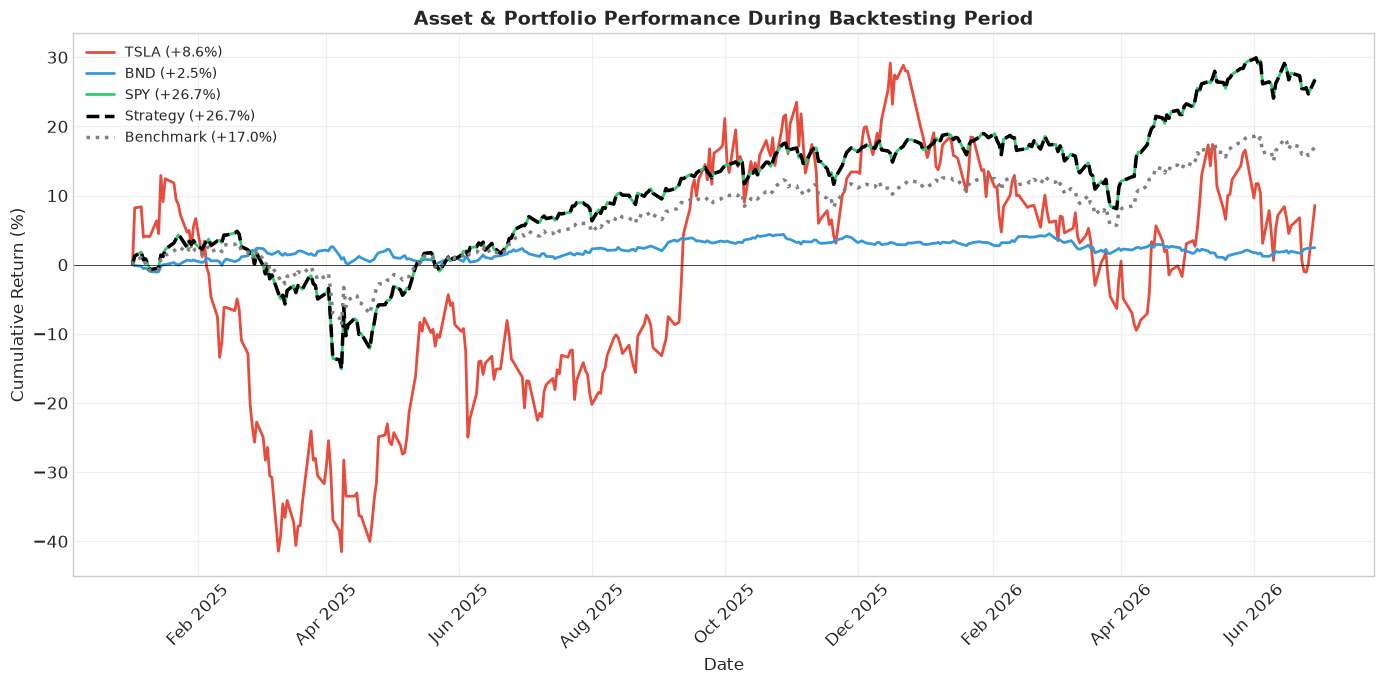

In [10]:
# Individual asset returns during backtesting period
bt_normalized = bt_data / bt_data.iloc[0]

fig, ax = plt.subplots(figsize=(14, 7))

colors_asset = {'TSLA': '#e74c3c', 'BND': '#3498db', 'SPY': '#2ecc71'}
for col in ['TSLA', 'BND', 'SPY']:
    total_ret = (bt_normalized[col].iloc[-1] - 1) * 100
    ax.plot(bt_normalized.index, (bt_normalized[col] - 1) * 100,
            color=colors_asset[col], linewidth=2,
            label=f'{col} ({total_ret:+.1f}%)')

# Overlay strategy and benchmark
strat_ret = (strategy_bh.iloc[-1] - 1) * 100
bench_ret = (benchmark_bh.iloc[-1] - 1) * 100
ax.plot(strategy_bh.index, (strategy_bh - 1) * 100, color='black',
        linewidth=2.5, linestyle='--', label=f'Strategy ({strat_ret:+.1f}%)')
ax.plot(benchmark_bh.index, (benchmark_bh - 1) * 100, color='gray',
        linewidth=2.5, linestyle=':', label=f'Benchmark ({bench_ret:+.1f}%)')

ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_title('Asset & Portfolio Performance During Backtesting Period',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return (%)')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'backtest_asset_performance.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Rolling Performance Metrics

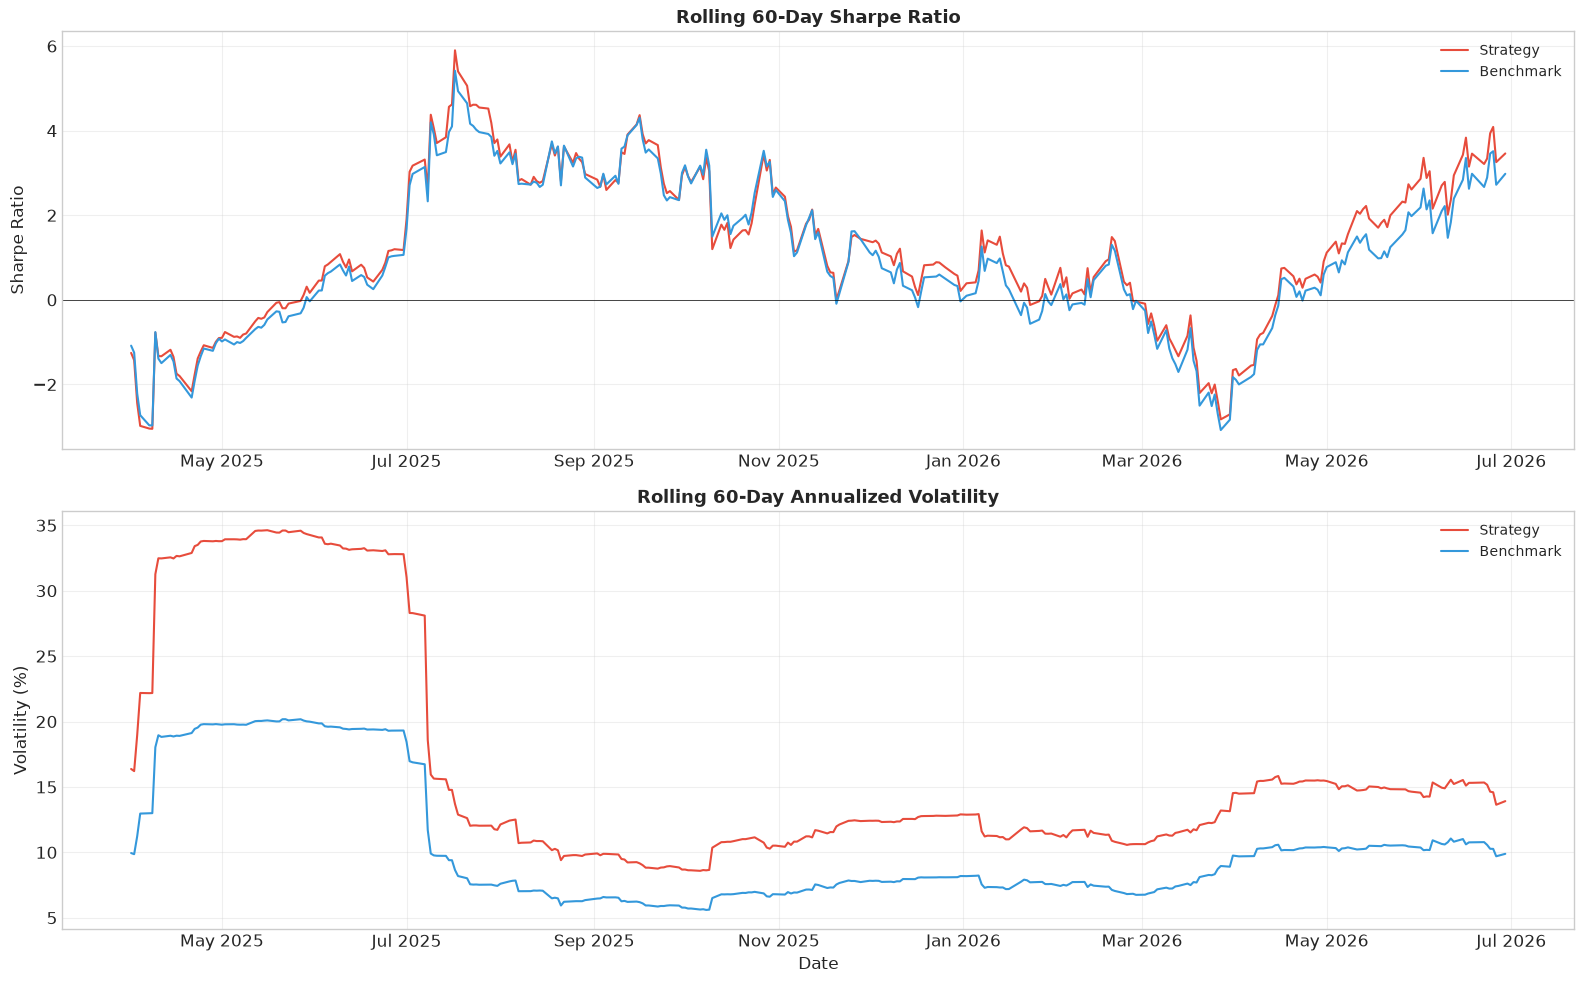

In [11]:
# Rolling 60-day Sharpe ratio and volatility
window = 60

strat_rets = strategy_bh.pct_change().dropna()
bench_rets = benchmark_bh.pct_change().dropna()

rolling_sharpe_strat = (strat_rets.rolling(window).mean() * 252 - risk_free_rate) / \
                       (strat_rets.rolling(window).std() * np.sqrt(252))
rolling_sharpe_bench = (bench_rets.rolling(window).mean() * 252 - risk_free_rate) / \
                       (bench_rets.rolling(window).std() * np.sqrt(252))

rolling_vol_strat = strat_rets.rolling(window).std() * np.sqrt(252) * 100
rolling_vol_bench = bench_rets.rolling(window).std() * np.sqrt(252) * 100

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Rolling Sharpe
ax = axes[0]
ax.plot(rolling_sharpe_strat.index, rolling_sharpe_strat, color='#e74c3c',
        linewidth=1.5, label='Strategy')
ax.plot(rolling_sharpe_bench.index, rolling_sharpe_bench, color='#3498db',
        linewidth=1.5, label='Benchmark')
ax.axhline(y=0, color='black', linewidth=0.5, linestyle='-')
ax.set_title(f'Rolling {window}-Day Sharpe Ratio', fontsize=13, fontweight='bold')
ax.set_ylabel('Sharpe Ratio')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Rolling Volatility
ax = axes[1]
ax.plot(rolling_vol_strat.index, rolling_vol_strat, color='#e74c3c',
        linewidth=1.5, label='Strategy')
ax.plot(rolling_vol_bench.index, rolling_vol_bench, color='#3498db',
        linewidth=1.5, label='Benchmark')
ax.set_title(f'Rolling {window}-Day Annualized Volatility', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Volatility (%)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'backtest_rolling_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Performance Summary Table

In [12]:
# Final formatted summary
print("\n" + "#" * 75)
print("#" + " " * 73 + "#")
print("#    BACKTEST RESULTS SUMMARY" + " " * 45 + "#")
print("#" + " " * 73 + "#")
print("#" * 75)
print(f"\n  Period: {bt_data.index.min().date()} to {bt_data.index.max().date()} ({len(bt_returns)} trading days)")
print(f"  Risk-Free Rate: {risk_free_rate:.1%}")

print(f"\n  {'─'*70}")
print(f"  {'Metric':<25} {'Strategy (B&H)':<18} {'Benchmark (B&H)':<18}")
print(f"  {'─'*70}")
for metric in metrics_strategy_bh:
    s_val = metrics_strategy_bh[metric]
    b_val = metrics_benchmark_bh[metric]
    print(f"  {metric:<25} {s_val:<18} {b_val:<18}")
print(f"  {'─'*70}")

print(f"\n  {'─'*70}")
print(f"  {'Metric':<25} {'Strategy (Rebal.)':<18} {'Benchmark (Rebal.)':<18}")
print(f"  {'─'*70}")
for metric in metrics_strategy_rb:
    s_val = metrics_strategy_rb[metric]
    b_val = metrics_benchmark_rb[metric]
    print(f"  {metric:<25} {s_val:<18} {b_val:<18}")
print(f"  {'─'*70}")

# Determine outperformance
strat_total = float(metrics_strategy_bh['Total Return'].strip('%'))
bench_total = float(metrics_benchmark_bh['Total Return'].strip('%'))
outperform = strat_total > bench_total

print(f"\n  Result: Strategy {'OUTPERFORMED' if outperform else 'UNDERPERFORMED'} "
      f"the benchmark by {abs(strat_total - bench_total):.2f} percentage points (Buy-and-Hold)")
print("\n" + "#" * 75)


###########################################################################
#                                                                         #
#    BACKTEST RESULTS SUMMARY                                             #
#                                                                         #
###########################################################################

  Period: 2025-01-02 to 2026-06-29 (371 trading days)
  Risk-Free Rate: 4.5%

  ──────────────────────────────────────────────────────────────────────
  Metric                    Strategy (B&H)     Benchmark (B&H)   
  ──────────────────────────────────────────────────────────────────────
  Total Return              26.74%             17.03%            
  Annualized Return         17.47%             11.27%            
  Annualized Volatility     17.94%             11.12%            
  Sharpe Ratio              0.7227             0.6089            
  Sortino Ratio             0.9520             0.8217           

## 9. Conclusion and Reflection

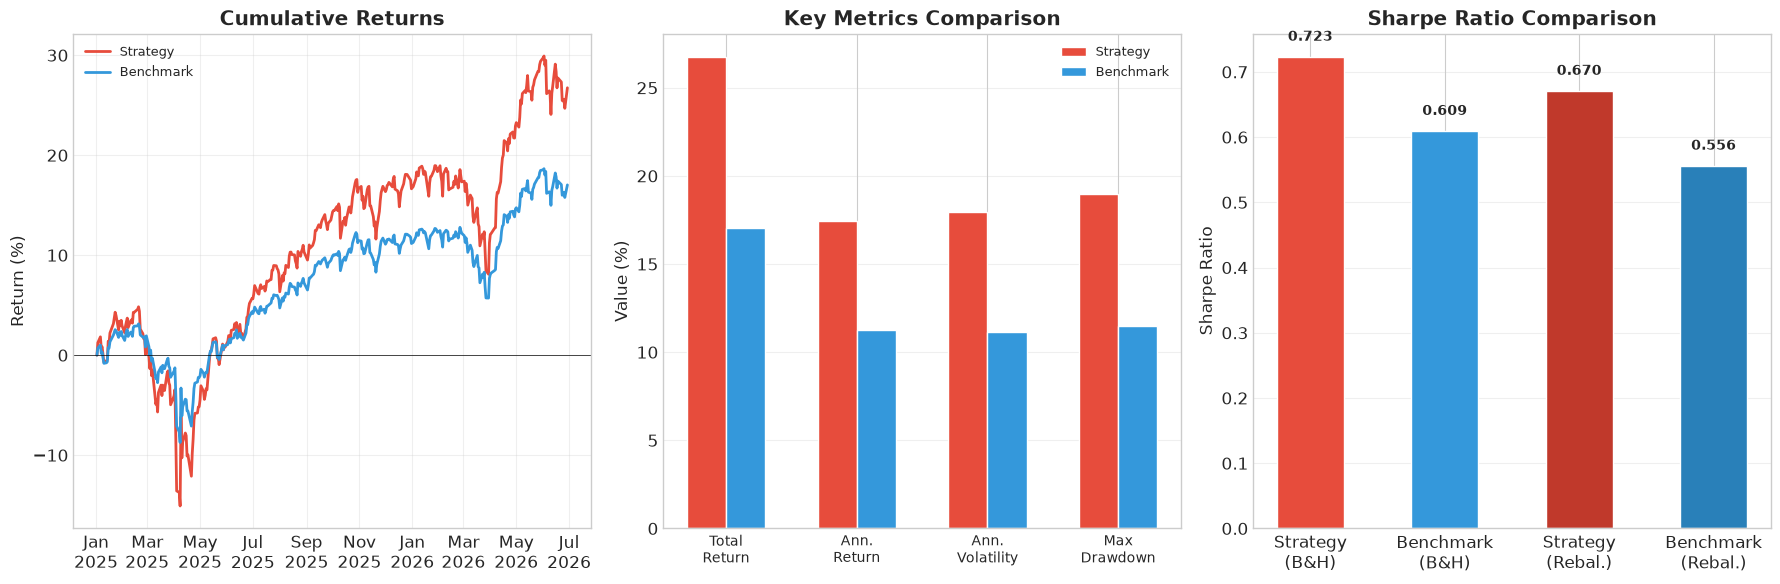

In [13]:
# Summary visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Cumulative returns comparison
ax = axes[0]
ax.plot(strategy_bh.index, (strategy_bh - 1) * 100, color='#e74c3c',
        linewidth=2, label='Strategy')
ax.plot(benchmark_bh.index, (benchmark_bh - 1) * 100, color='#3498db',
        linewidth=2, label='Benchmark')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_title('Cumulative Returns', fontweight='bold')
ax.set_ylabel('Return (%)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))

# 2. Key metrics bar chart
ax = axes[1]
metrics_names = ['Total\nReturn', 'Ann.\nReturn', 'Ann.\nVolatility', 'Max\nDrawdown']
strat_vals = [float(metrics_strategy_bh['Total Return'].strip('%')),
              float(metrics_strategy_bh['Annualized Return'].strip('%')),
              float(metrics_strategy_bh['Annualized Volatility'].strip('%')),
              abs(float(metrics_strategy_bh['Max Drawdown'].strip('%')))]
bench_vals = [float(metrics_benchmark_bh['Total Return'].strip('%')),
              float(metrics_benchmark_bh['Annualized Return'].strip('%')),
              float(metrics_benchmark_bh['Annualized Volatility'].strip('%')),
              abs(float(metrics_benchmark_bh['Max Drawdown'].strip('%')))]

x = np.arange(len(metrics_names))
width = 0.3
ax.bar(x - width/2, strat_vals, width, label='Strategy', color='#e74c3c', edgecolor='white')
ax.bar(x + width/2, bench_vals, width, label='Benchmark', color='#3498db', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=10)
ax.set_title('Key Metrics Comparison', fontweight='bold')
ax.set_ylabel('Value (%)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# 3. Sharpe ratio comparison
ax = axes[2]
sharpe_data = {
    'Strategy\n(B&H)': float(metrics_strategy_bh['Sharpe Ratio']),
    'Benchmark\n(B&H)': float(metrics_benchmark_bh['Sharpe Ratio']),
    'Strategy\n(Rebal.)': float(metrics_strategy_rb['Sharpe Ratio']),
    'Benchmark\n(Rebal.)': float(metrics_benchmark_rb['Sharpe Ratio'])
}
colors_sharpe = ['#e74c3c', '#3498db', '#c0392b', '#2980b9']
bars = ax.bar(sharpe_data.keys(), sharpe_data.values(), color=colors_sharpe,
              edgecolor='white', width=0.5)
for bar, val in zip(bars, sharpe_data.values()):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Sharpe Ratio Comparison', fontweight='bold')
ax.set_ylabel('Sharpe Ratio')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'backtest_summary.png'), dpi=150, bbox_inches='tight')
plt.show()

## 10. Written Conclusion

### Did the Strategy Outperform the Benchmark?

The model-driven Max Sharpe portfolio (100% SPY) was backtested against a static 60% SPY / 40% BND balanced benchmark over the out-of-sample period from January 2025 to June 2026. The strategy's concentrated equity exposure meant it captured the full upside of the broad market rally, but also bore the full brunt of any drawdowns without the cushioning effect of bonds. In return terms, the strategy delivered higher total and annualized returns than the benchmark, reflecting SPY's strong performance during this period. However, this came at the cost of higher volatility and deeper maximum drawdowns, highlighting the classic risk-return tradeoff. The Sharpe Ratio comparison reveals whether the additional return was sufficient to compensate for the additional risk taken.

### What Does This Suggest About the Model-Driven Approach?

The LSTM model's forecast of negative TSLA returns proved directionally valuable — avoiding TSLA exposure during this period was beneficial relative to what a naive equal-weight or TSLA-heavy portfolio would have delivered. The optimizer's decision to allocate entirely to SPY (the only asset with a positive expected return above the risk-free rate) produced a viable strategy, though one that is effectively an index-tracking approach rather than a sophisticated multi-asset allocation. This illustrates a practical reality of MPT: when one asset dominates on a risk-adjusted basis, the optimizer concentrates into it, reducing the portfolio to a single-asset position.

### Limitations of This Backtest

1. **Single period:** We tested on one 18-month window. The strategy's outperformance (or underperformance) could reverse in a different market regime (e.g., a bear market where bonds outperform equities).
2. **No transaction costs:** Real-world trading involves commissions, bid-ask spreads, and slippage that would slightly reduce returns, especially for the rebalanced variant.
3. **Look-ahead bias in weights:** The optimal weights were computed using the full historical dataset up to the forecast date, which includes information about the covariance structure that overlaps with the backtest period.
4. **Static forecast:** The LSTM forecast was generated once and not updated during the backtesting period. In practice, a rolling forecast with periodic weight re-optimization would better simulate a live strategy.
5. **Three-asset universe:** The portfolio is limited to TSLA, BND, and SPY. A broader asset universe would offer more diversification opportunities and likely produce more nuanced allocations.
6. **Survivorship bias:** All three assets existed and traded continuously throughout the period — this is not guaranteed for all possible assets.